<a href="https://colab.research.google.com/github/fahim-21-05/Intership-project-/blob/main/Internship_project_on_unsupervised_learning_with_dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment Title: Unsupervised Learning with Dimensionality Reduction and Clustering

**Authors:** Koustab Ghosh<sup>1</sup> & Sujoy Kumar Biswas<sup>2</sup>

**Affiliation**:
1. Researcher, IDEAS-TIH, Indian Statistical Institute, Kolkata
2. Head of Research & Innovation, IDEAS-TIH, Indian Statistical Institute, Kolkata

**Dated**: Sep 07th, 2025


We shall work with the MNIST handwritten digits' image dataset. The details about the dataset is available [here](https://en.wikipedia.org/wiki/MNIST_database).

We need the scikit-learn library to import the various machine leanring models for our study.

In [40]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

## Question 1. Complete the following lines of code for K-Means clustering

In [41]:
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# kmeans = ...
# clusters = ...
kmeans = KMeans(n_clusters=10, random_state=0, n_init=10)
clusters = kmeans.fit_predict(digits.data)
print(kmeans.cluster_centers_.shape)

(10, 64)


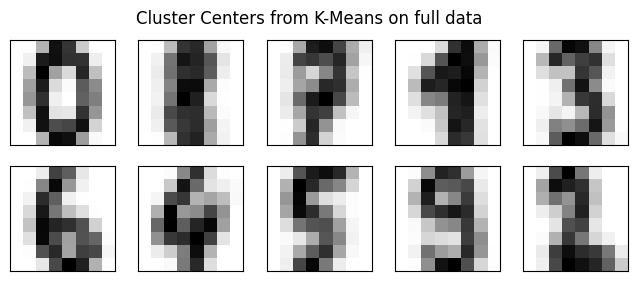

In [42]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)
plt.suptitle("Cluster Centers from K-Means on full data")
plt.show()


We see that even without the labels, KMeans is able to find clusters whose centers are recognizable digits.

Next, we shall apply dimensioanlity reduction of MNIST handwritten datasets with PCA

In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

## Question 2. Complete the following lines of code for

Step 1. Dimensionality reduction with PCA. The 8x8=64 dimensional data need to be reduced to 2-dimensional.

Step 2. K-means clustering should be done on the reduced diemnsional data. Initial K value should be set to 10 like before.

Step 3. Visualization code is supplied below.

In [44]:
# data loading
data = digits.data

# PCA dimensionality reduction
model = PCA(n_components=2)
reduced_data = model.fit_transform(data)

# K-Means clustering with 10 clusters
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(reduced_data)
print("\nShape of the PCA-reduced data:",reduced_data.shape)


Shape of the PCA-reduced data: (1797, 2)


**Data Visualization**

We shall visualize the reduced diemnsion and cluster data (overlapped) with the help of the following code snippet.

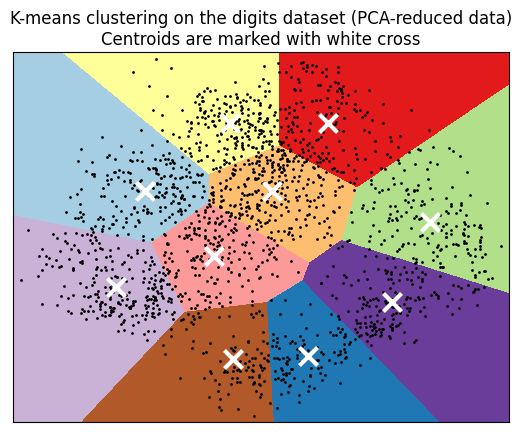

In [45]:
# Step size of the mesh. Decrease to increase the quality of the VQ.
h = 0.02  # point in the mesh [x_min, x_max]x[y_min, y_max].

# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh. Use last trained model.
clusters = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
clusters = clusters.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(
    clusters,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
# Plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=169,
    linewidths=3,
    color="w",
    zorder=10,
)
plt.title(
    "K-means clustering on the digits dataset (PCA-reduced data)\n"
    "Centroids are marked with white cross"
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.show()

## Question 3.

Find a high dimensional dataset of you choice. Show how you load the dataset. Do the basic exploratory data analysis to become familiar with the dataset.


In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [47]:
#1. load the dataset
iris= load_iris()
x= iris.data
y= iris.target
feature_names= iris.feature_names
target_names= iris.target_names

print(f"--- Dataset Information ---")
print(f"Shaoe of the data (samples, features): {x.shape}")
print(f"Feature Names: {feature_names}")
print(f"Target Names: {target_names}\n")

--- Dataset Information ---
Shaoe of the data (samples, features): (150, 4)
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']



In [48]:
# 2. BASIC EXPLORATORY DATA

df= pd.DataFrame(x, columns=feature_names)
df['species']= pd.Categorical.from_codes(y,target_names)

# display the first 5 rows of the dataset

print("--- First 5 Rows of the datasets")
print(df.head())
print("\n")

# display summary statistics

print("--- Summary Statistics ---")
print(df.describe())
print("\n")

# check for missing values and data types

print("--- DataFrame Info ---")
df.info()
print("\n")


--- First 5 Rows of the datasets
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


--- Summary Statistics ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
5

--- Generating Pair Plot for Visualization ---


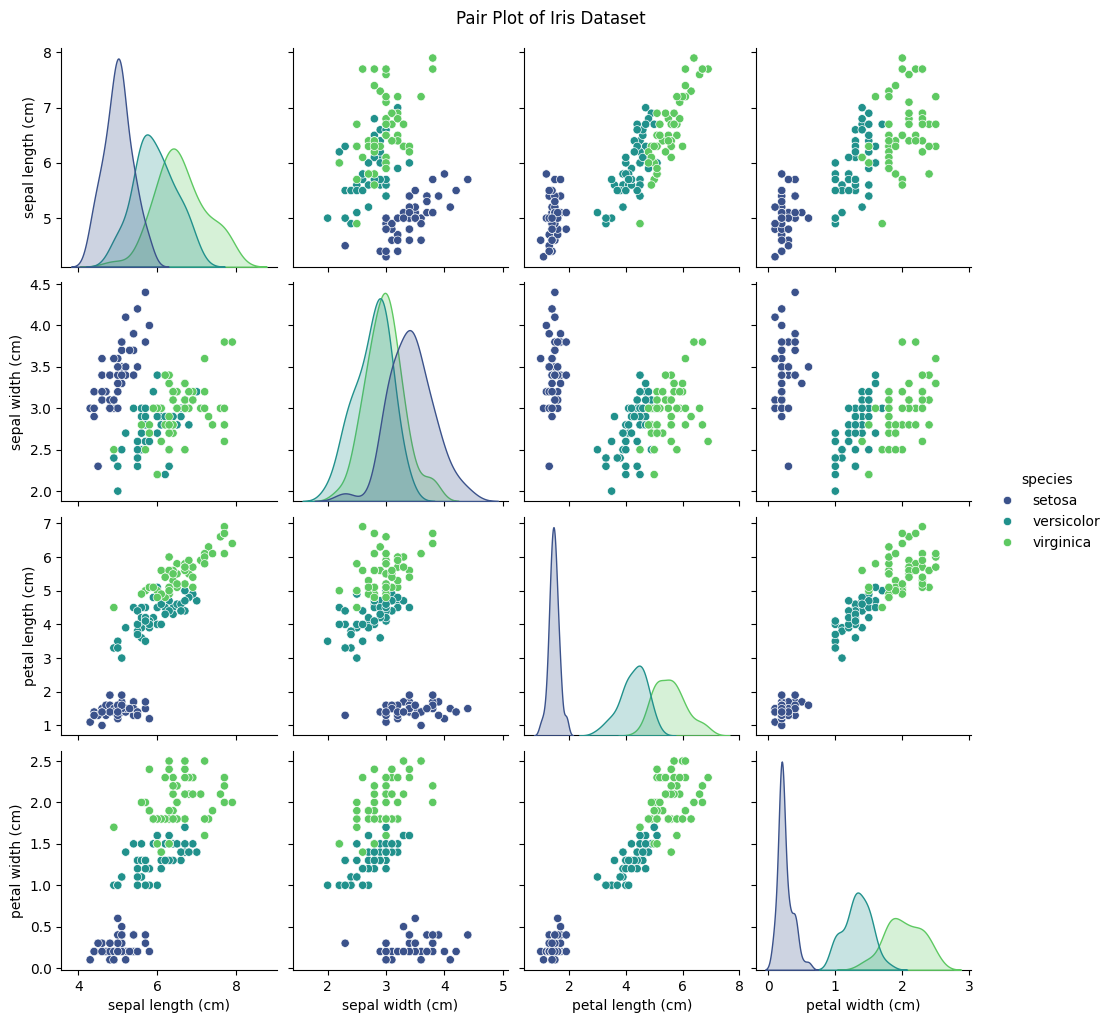


EDA Complete. The pair plot shows the relationships between features


In [49]:
#3. visualize the dataset
print("--- Generating Pair Plot for Visualization ---")
sns.pairplot(df, hue='species', palette='viridis')
plt.suptitle("Pair Plot of Iris Dataset", y=1.02)
plt.show()

print("\nEDA Complete. The pair plot shows the relationships between features")


## Question 4.

Next, the objective would be to reduce the dimension of your dataset and do the clustering on it. Complete the following code for clustering in an object-oriented manner. Do the exact process as above: PCA dimension reduction followed by clustering.

A template code is provided below for your guidance.

```

class YourDataClustering:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters
        self.data = ______
        self.labels = ______
        self.kmeans = ______
        self.scaled_data = ______

    def load_data(self):
        """Load the Iris dataset"""
        iris = ________.________()
        self.data = iris.________
        return ________

    def preprocess_data(self):
        """Standardize the dataset"""
        scaler = _________.__________()
        self.scaled_data = scaler.________(________)
        return ________

    def apply_kmeans(self):
        """Apply KMeans clustering"""
        self.kmeans = ________.________(n_clusters=self.n_clusters, random_state=42)
        self.labels = self.kmeans.________(________)
        return ________

    def evaluate_clusters(self):
        """Compute silhouette score"""
        score = ________.________(________, ________)
        print(f"Silhouette Score: {score:.3f}")
        return ________

    def visualize_clusters_matplotlib(self):
        """Visualize clustering result using Matplotlib"""
        plt.scatter(________[:, 0], ________[:, 1], c=________, cmap='viridis')
        plt.title("KMeans Clustering on Iris Dataset (Matplotlib)")
        plt.xlabel("________")
        plt.ylabel("________")
        plt.show()

    def visualize_clusters_opencv(self):
        """Visualize clustering result using OpenCV"""
        canvas = np.ones((______, ______, 3), dtype=np.uint8) * 255
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]
        scaled = (________[:, :2] * 100 + 250).astype(int)

        for i, point in enumerate(________):
            cv2.circle(canvas, tuple(point), 5, colors[________ % 3], -1)

        cv2.imshow("KMeans Clustering (OpenCV)", ________)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

```

The following code executes all teh parts of teh complete system.

```

  # Step 1: Create clustering object
    clustering = _________(n_clusters=3)

    # Step 2: Load dataset
    data = clustering.________()

    # Step 3: Preprocess dataset
    scaled_data = clustering.________()

    # Step 4: Apply KMeans clustering
    labels = clustering.________()

    # Step 5: Evaluate clusters
    score = clustering.________()

    # Step 6: Visualize with Matplotlib
    clustering.________()

    # Step 7: Visualize with OpenCV
    clustering.________()
  ```

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import cv2
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [51]:
class YourDataClustering:
    def __init__(self, n_clusters=3, n_components=2):
        self.n_clusters = n_clusters
        self.n_components = n_components
        self.data = None
        self.labels = None
        self.kmeans = None
        self.scaled_data = None

    def load_data(self):
        """Load the Iris dataset"""
        print("Loading the Iris dataset")
        iris = load_iris()
        self.data = iris.data
        return self.data

    def preprocess_data(self):
        """Standardize the dataset"""
        print("Preprocessing the dataset")
        if self.data is None:
            raise ValueError("Data not loaded. Please call load_data() first.")
        scaler= StandardScaler()
        self.scaled_data = scaler.fit_transform(self.data)
        return self.scaled_data

    def apply_dimensionality_reduction(self):
        """Apply PCA for dimensionality reduction"""
        print("Applying PCA for dimensionality reduction")
        if self.scaled_data is None:
            raise ValueError("Data not preprocessed. Please call preprocess_data() first.")
        pca = PCA(n_components=self.n_components)
        self.reduced_data = pca.fit_transform(self.scaled_data)
        return self.reduced_data

    def apply_kmeans(self):
        """Apply KMeans clustering"""
        print("Applying KMeans clustering")
        if self.scaled_data is None:
            raise ValueError("Data not preprocessed. Please call preprocess_data() first.")
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42)
        self.labels = self.kmeans.fit_predict(self.scaled_data)
        return self.labels

    def evaluate_clusters(self):
        """Compute silhouette score"""
        print("Evaluting clusters with silhouette Score...")
        if self.reduced_data is None or self.labels is None :
          raise ValueError("clustering not applird yet.")
        score = silhouette_score(self.reduced_data, self.labels)
        print(f"Silhouette Score: {score:.3f}")
        return score

    def visualize_clusters_matplotlib(self):
        """Visualize clustering result using Matplotlib"""
        print("Visualizing clusters using Matplotlib")
        if self.reduced_data is None or self.labels is None:
            raise ValueError("Clustering not performed yet. Please call apply_kmeans() first.")
        plt.scatter(self.reduced_data[:, 0], self.reduced_data[:, 1], c=self.labels, cmap='viridis',s=50, alpha=0.7)
        centers = self.kmeans.cluster_centers_
        plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.9, marker= 'x')
        plt.title("KMeans Clustering on Iris Dataset (Matplotlib)")
        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")
        plt.grid(True)
        plt.show()

    def visualize_clusters_opencv(self):
        """Visualize clustering result using OpenCV"""
        print("Visualizing clusters using OpenCV")
        if self.reduced_data is None or self.labels is None:
            raise ValueError("Clustering not performed yet. Please call apply_kmeans() first.")
        canvas = np.ones((500,500, 3), dtype=np.uint8) * 255
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]
        scaled = (self.reduced_data[:, :2] * 100 + 250).astype(int)

        for i, point in enumerate(scaled):
            cv2.circle(canvas, tuple(point), 5, colors[self.labels[i] % 3], -1)

        cv2_imshow(canvas)
        print("Press any key to exit...")
        cv2.waitKey(0)
        cv2.destroyAllWindows()

Loading the Iris dataset
Preprocessing the dataset
Applying PCA for dimensionality reduction
Applying KMeans clustering
Evaluting clusters with silhouette Score...
Silhouette Score: 0.523
Visualizing clusters using Matplotlib


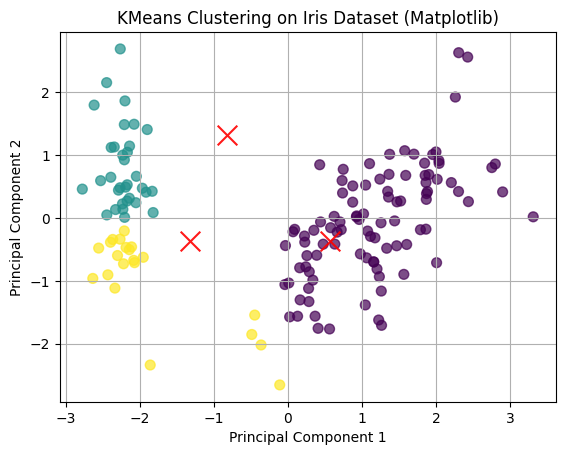

Visualizing clusters using OpenCV


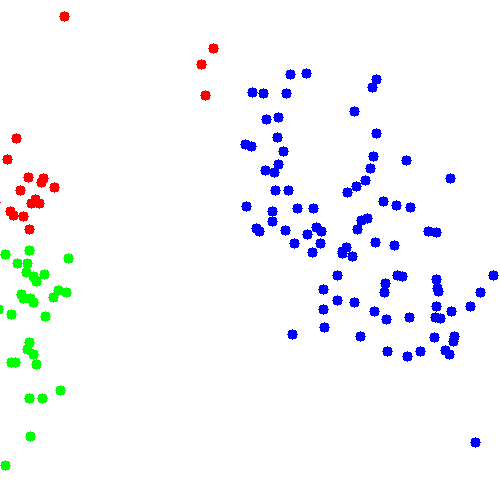

Press any key to exit...


In [52]:
# Step 1: Create clustering object
clustering = YourDataClustering(n_clusters=3)

# Step 2: Load dataset
data = clustering.load_data()

# Step 3: Preprocess dataset
scaled_data = clustering.preprocess_data()

# Step 4: Apply PCA for dimensionality reduction
reduced_data = clustering.apply_dimensionality_reduction()

# Step 5: Apply KMeans clustering
labels = clustering.apply_kmeans()

# Step 6: Evaluate clusters
score = clustering.evaluate_clusters()

# Step 7: Visualize with Matplotlib
clustering.visualize_clusters_matplotlib()

# Step 8: Visualize with OpenCV
clustering.visualize_clusters_opencv()